In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

## Reading the data in


In [14]:
# df = pd.read_csv("../db.csv")
df = pd.read_csv("output.csv")

df.head()

,number,RSRP,RSSI,RSRQ,SNR,CINR,MOS
0,0,-100,-74.0,-199.000000,12.762571,10.097029,4.002256
1,1,-97,-67.0,-154.000000,16.509812,13.382265,3.957574
2,2,-91,-60.0,-167.078556,17.658596,14.177795,4.011303
3,3,-103,-59.0,-175.000000,16.772214,13.420014,3.735515
4,4,-114,-87.0,-251.900407,8.051354,5.350529,3.091996


In [15]:
df.describe()

,number,RSRP,RSSI,RSRQ,SNR,CINR,MOS
count,6577.000000,6577.000000,6577.000000,6577.000000,6577.000000,6577.000000,6577.000000
mean,3288.000000,-97.889919,-69.034219,-164.247182,13.699293,10.621857,3.830348
std,1898.760692,9.966079,8.450631,51.623930,3.898197,3.463137,0.421735
min,0.000000,-120.000000,-88.000000,-300.000000,5.027034,3.125703,2.124065
25%,1644.000000,-104.000000,-74.565994,-199.000000,10.910084,8.427702,3.563582
50%,3288.000000,-98.000000,-69.735243,-158.041512,13.608754,10.183022,3.865824
75%,4932.000000,-90.000000,-62.000000,-124.000000,16.214658,12.725402,4.142504
max,6576.000000,-74.000000,-48.000000,-70.000000,24.993545,22.798188,4.663097


Let's select some features that we want to use for regression.


In [16]:
cdf = df[['RSRP','RSSI','RSRQ','SNR','CINR','MOS']]
cdf.head(9)

,RSRP,RSSI,RSRQ,SNR,CINR,MOS
0,-100,-74.0,-199.000000,12.762571,10.097029,4.002256
1,-97,-67.0,-154.000000,16.509812,13.382265,3.957574
2,-91,-60.0,-167.078556,17.658596,14.177795,4.011303
3,-103,-59.0,-175.000000,16.772214,13.420014,3.735515
4,-114,-87.0,-251.900407,8.051354,5.350529,3.091996
5,-93,-71.0,-153.000000,15.141504,11.221046,4.103253
6,-98,-80.0,-199.000000,9.435822,7.316136,4.106670
7,-98,-63.0,-137.000000,14.291165,10.596028,3.935012
8,-85,-65.0,-96.091045,15.091750,11.312935,4.345557


Let's plot Emission values with respect to Engine size:


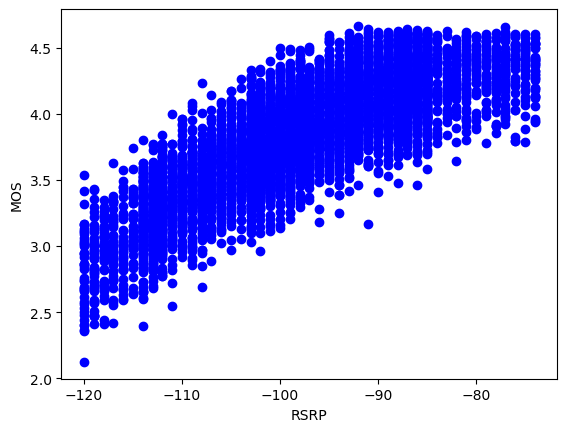

In [17]:
plt.scatter(cdf.RSRP, cdf.MOS,  color='blue')
plt.xlabel("RSRP")
plt.ylabel("MOS")
plt.show()

#### Creating train and test dataset

Train/Test Split involves splitting the dataset into training and testing sets respectively, which are mutually exclusive. After which, you train with the training set and test with the testing set.


In [18]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

<h2 id="polynomial_regression">Polynomial regression</h2>


In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
train_x = np.asanyarray(train[['RSRP','RSSI','RSRQ','SNR','CINR']])
train_y = np.asanyarray(train[['MOS']])

test_x = np.asanyarray(test[['RSRP','RSSI','RSRQ','SNR','CINR']])
test_y = np.asanyarray(test[['MOS']])


poly = PolynomialFeatures(degree=2)
train_x_poly = poly.fit_transform(train_x)
print(train_x)
print(len(train_x_poly[0]))
train_x_poly[0]

[[-100.          -74.         -199.           12.7625705    10.09702894]
 [ -97.          -67.         -154.           16.50981178   13.38226477]
 [ -91.          -60.         -167.07855575   17.65859585   14.17779467]
 ...
 [ -90.          -66.         -129.           11.83984026    8.61749988]
 [-102.          -69.4622405  -192.            9.37495287    6.63069426]
 [ -96.          -59.         -111.           11.8749056     8.68933882]]
21


array([ 1.00000000e+00, -1.00000000e+02, -7.40000000e+01, -1.99000000e+02,
        1.27625705e+01,  1.00970289e+01,  1.00000000e+04,  7.40000000e+03,
        1.99000000e+04, -1.27625705e+03, -1.00970289e+03,  5.47600000e+03,
        1.47260000e+04, -9.44430217e+02, -7.47180142e+02,  3.96010000e+04,
       -2.53975153e+03, -2.00930876e+03,  1.62883206e+02,  1.28864044e+02,
        1.01949993e+02])

In [20]:
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly, train_y)
# The coefficients
print ('Coefficients size: ', len(clf.coef_[0]))
print ('Coefficients: ', clf.coef_)
print ('Intercept: ',clf.intercept_)

Coefficients size:  21
Coefficients:  [[ 0.00000000e+00 -1.27257279e-01  5.90649277e-03  1.67456203e-03
   1.61204897e-01 -1.10996421e-01 -8.36484486e-04  1.26635643e-04
   1.50725976e-05  1.51154675e-03 -1.07321220e-03 -4.47442805e-05
   3.25340823e-06  8.61197021e-04 -1.10234488e-03 -1.76728886e-06
  -2.93646245e-04  3.33019490e-04  2.53231518e-03 -6.02693206e-03
   2.83225476e-03]]
Intercept:  [-0.84276391]


<h2 id="evaluation">Evaluation</h2>


In [21]:
from sklearn.metrics import r2_score

test_x_poly = poly.fit_transform(test_x)
test_y_ = clf.predict(test_x_poly)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y,test_y_ ) )

Mean absolute error: 0.18
Residual sum of squares (MSE): 0.05
R2-score: 0.70


### now predict

In [22]:
example_sample=[[-100,-74.0,-199.0,12.762570504157006,10.097028941237086]]
example_poly=poly.fit_transform(example_sample)
result = clf.predict(example_poly)
result

array([[3.82043531]])